In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import mas_skipper_utils as msu 

from astropy.io import fits
from astropy.table import Table
from astropy.visualization import ZScaleInterval
from matplotlib import rcParams
#from astropy.timeseries import LombScargle
from astropy.stats import sigma_clipped_stats, SigmaClip
from astropy.visualization import SqrtStretch, ImageNormalize, AsinhStretch

from mpl_toolkits.axes_grid1 import make_axes_locatable 
#from sklearn.linear_model import LinearRegression

# Set the colorblind-friendly palette
sns.set_palette("colorblind")

from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture, aperture_photometry
from photutils.background import Background2D, MedianBackground

In [2]:
# Set Matplotlib style for publication (PASP-like)
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']  # Fallbacks
rcParams['font.size'] = 12
rcParams['axes.labelsize'] = 14
rcParams['axes.titlesize'] = 14
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 12
rcParams['legend.fontsize'] = 12
rcParams['figure.dpi'] = 300
rcParams['savefig.bbox'] = 'tight'
rcParams['savefig.format'] = 'png'

In [ ]:
# Define paths (adjust if needed)
name = "comb_cfbo_DIRECTV14_0394_ov_5s_1"
path = "/home/allon/Escritorio/new_ptcs/bsw/sci_imageshh3/DIRECTV14_V_Red22/comb/"
obj = path + name + ".fits"

# Load the FITS image (assumes data in first extension; adjust if multi-extension)
with fits.open(obj) as hdul:
    data = hdul[1].data  # or hdul[1].data if in extension 1
    header = hdul[1].header

msu.show_fits_image(data)

# Compute background and subtract it
bkg = Background2D(data, box_size=(50, 50), filter_size=(3, 3), sigma_clip=SigmaClip(sigma=3.0))  # Fixed: Pass SigmaClip object
bkg_data = bkg.background
data_sub = data - bkg_data

# Estimate noise for detection (use sigma-clipped stats on background)
_, bkg_rms, bkg_std = sigma_clipped_stats(bkg_data, sigma=3.0)
print(f"Background RMS: {bkg_rms:.2f} ADU")  # Inspect this value

# Detect sources using DAOStarFinder (adjust parameters as needed)
daofind = DAOStarFinder(fwhm=3.5, threshold=5.0 * 130) #IMPORTANT: Instead of bgk_rms
sources = daofind(data_sub)

if sources is None:
    sources = daofind(data_sub)  # Fallback without explicit background subtraction
    print("No sources detected; check threshold/FWHM.")

# Extract positions (x, y in pixels)
positions = np.transpose((sources['xcentroid'], sources['ycentroid']))

# Define aperture radius (e.g., 3 * FWHM; adjust based on seeing)
aperture_radius = 25.0  # in pixels

# Perform aperture photometry
apertures = CircularAperture(positions, r=aperture_radius)
phot_table = aperture_photometry(data_sub, apertures)

# Add magnitude column (assuming zero-point from header or set manually)
zeropoint = header.get('ZP', 0.0)  # Replace with actual ZP if known. Default is 25

# Compute magnitudes, masking invalid sums
valid_mask = phot_table['aperture_sum'] > 0
phot_table['mag'] = np.full(len(phot_table), np.nan)  # Initialize with NaN
phot_table['mag'][valid_mask] = -2.5 * np.log10(phot_table['aperture_sum'][valid_mask]) + zeropoint

# Visualization: Plot original image with detections and apertures
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))  # Increased height to accommodate decorations

# Left: Original image with detected sources marked (use SqrtStretch, assumes non-negative data)
#norm1 = ImageNormalize(data, stretch=SqrtStretch(), vmin=np.nanmin(data), vmax=np.nanpercentile(data, 99))
ax1.imshow(data, cmap='gray', origin='lower')#),norm=norm1)
ax1.plot(positions[:, 0], positions[:, 1], 'o', color='red', markersize=4, label='Detected sources')
ax1.set_title('Original Image with Detections')
ax1.set_xlabel('X (pixels)')
ax1.set_ylabel('Y (pixels)')
ax1.legend()

# Right: Background-subtracted with apertures overlaid (use AsinhStretch for negatives)
#norm2 = ImageNormalize(data_sub, stretch=AsinhStretch(), vmin=np.nanpercentile(data_sub, 1), vmax=np.nanpercentile(data_sub, 99))
ax2.imshow(data_sub, cmap='gray', origin='lower')#,norm=norm2)
apertures.plot(axes=ax2, color='cyan', lw=2, label='Apertures')
ax2.set_title('Background-Subtracted with Apertures')
ax2.set_xlabel('X (pixels)')
ax2.set_ylabel('Y (pixels)')
ax2.legend()

#plt.tight_layout()
#plt.subplots_adjust(hspace=0.3)
plt.savefig('photometry_visualization.png', dpi=150, bbox_inches='tight')  # Save plot
plt.show()  # Display interactively

# Print summary of photometry results (filter for positive sums only)
positive_mask = phot_table['aperture_sum'] > 0
print(phot_table[positive_mask])  # Show only valid photometry

# Optional: Save catalog to FITS table
phot_table.write('aperture_photometry_results.fits', overwrite=True)
print("Results saved to 'aperture_photometry_results.fits'")

# LAST GROK OUTPUT:

FITS file: /home/allon/Escritorio/new_ptcs/bsw/sci_imageshh3/DIRECTV14_V_Red22/comb/comb_cfbo_DIRECTV14_0394_ov_5s_1.fits
Number of HDUs: 2
HDU 0: PRIMARY - Shape: No data
HDU 1: IMAGE - Shape: (200, 511)
Data loaded from HDU 1, shape: (200, 511)
Background RMS: 17.60 ADU
Brightest source at (452.0, 67.5), zooming to [352.0:511.0, 0.0:167.5]


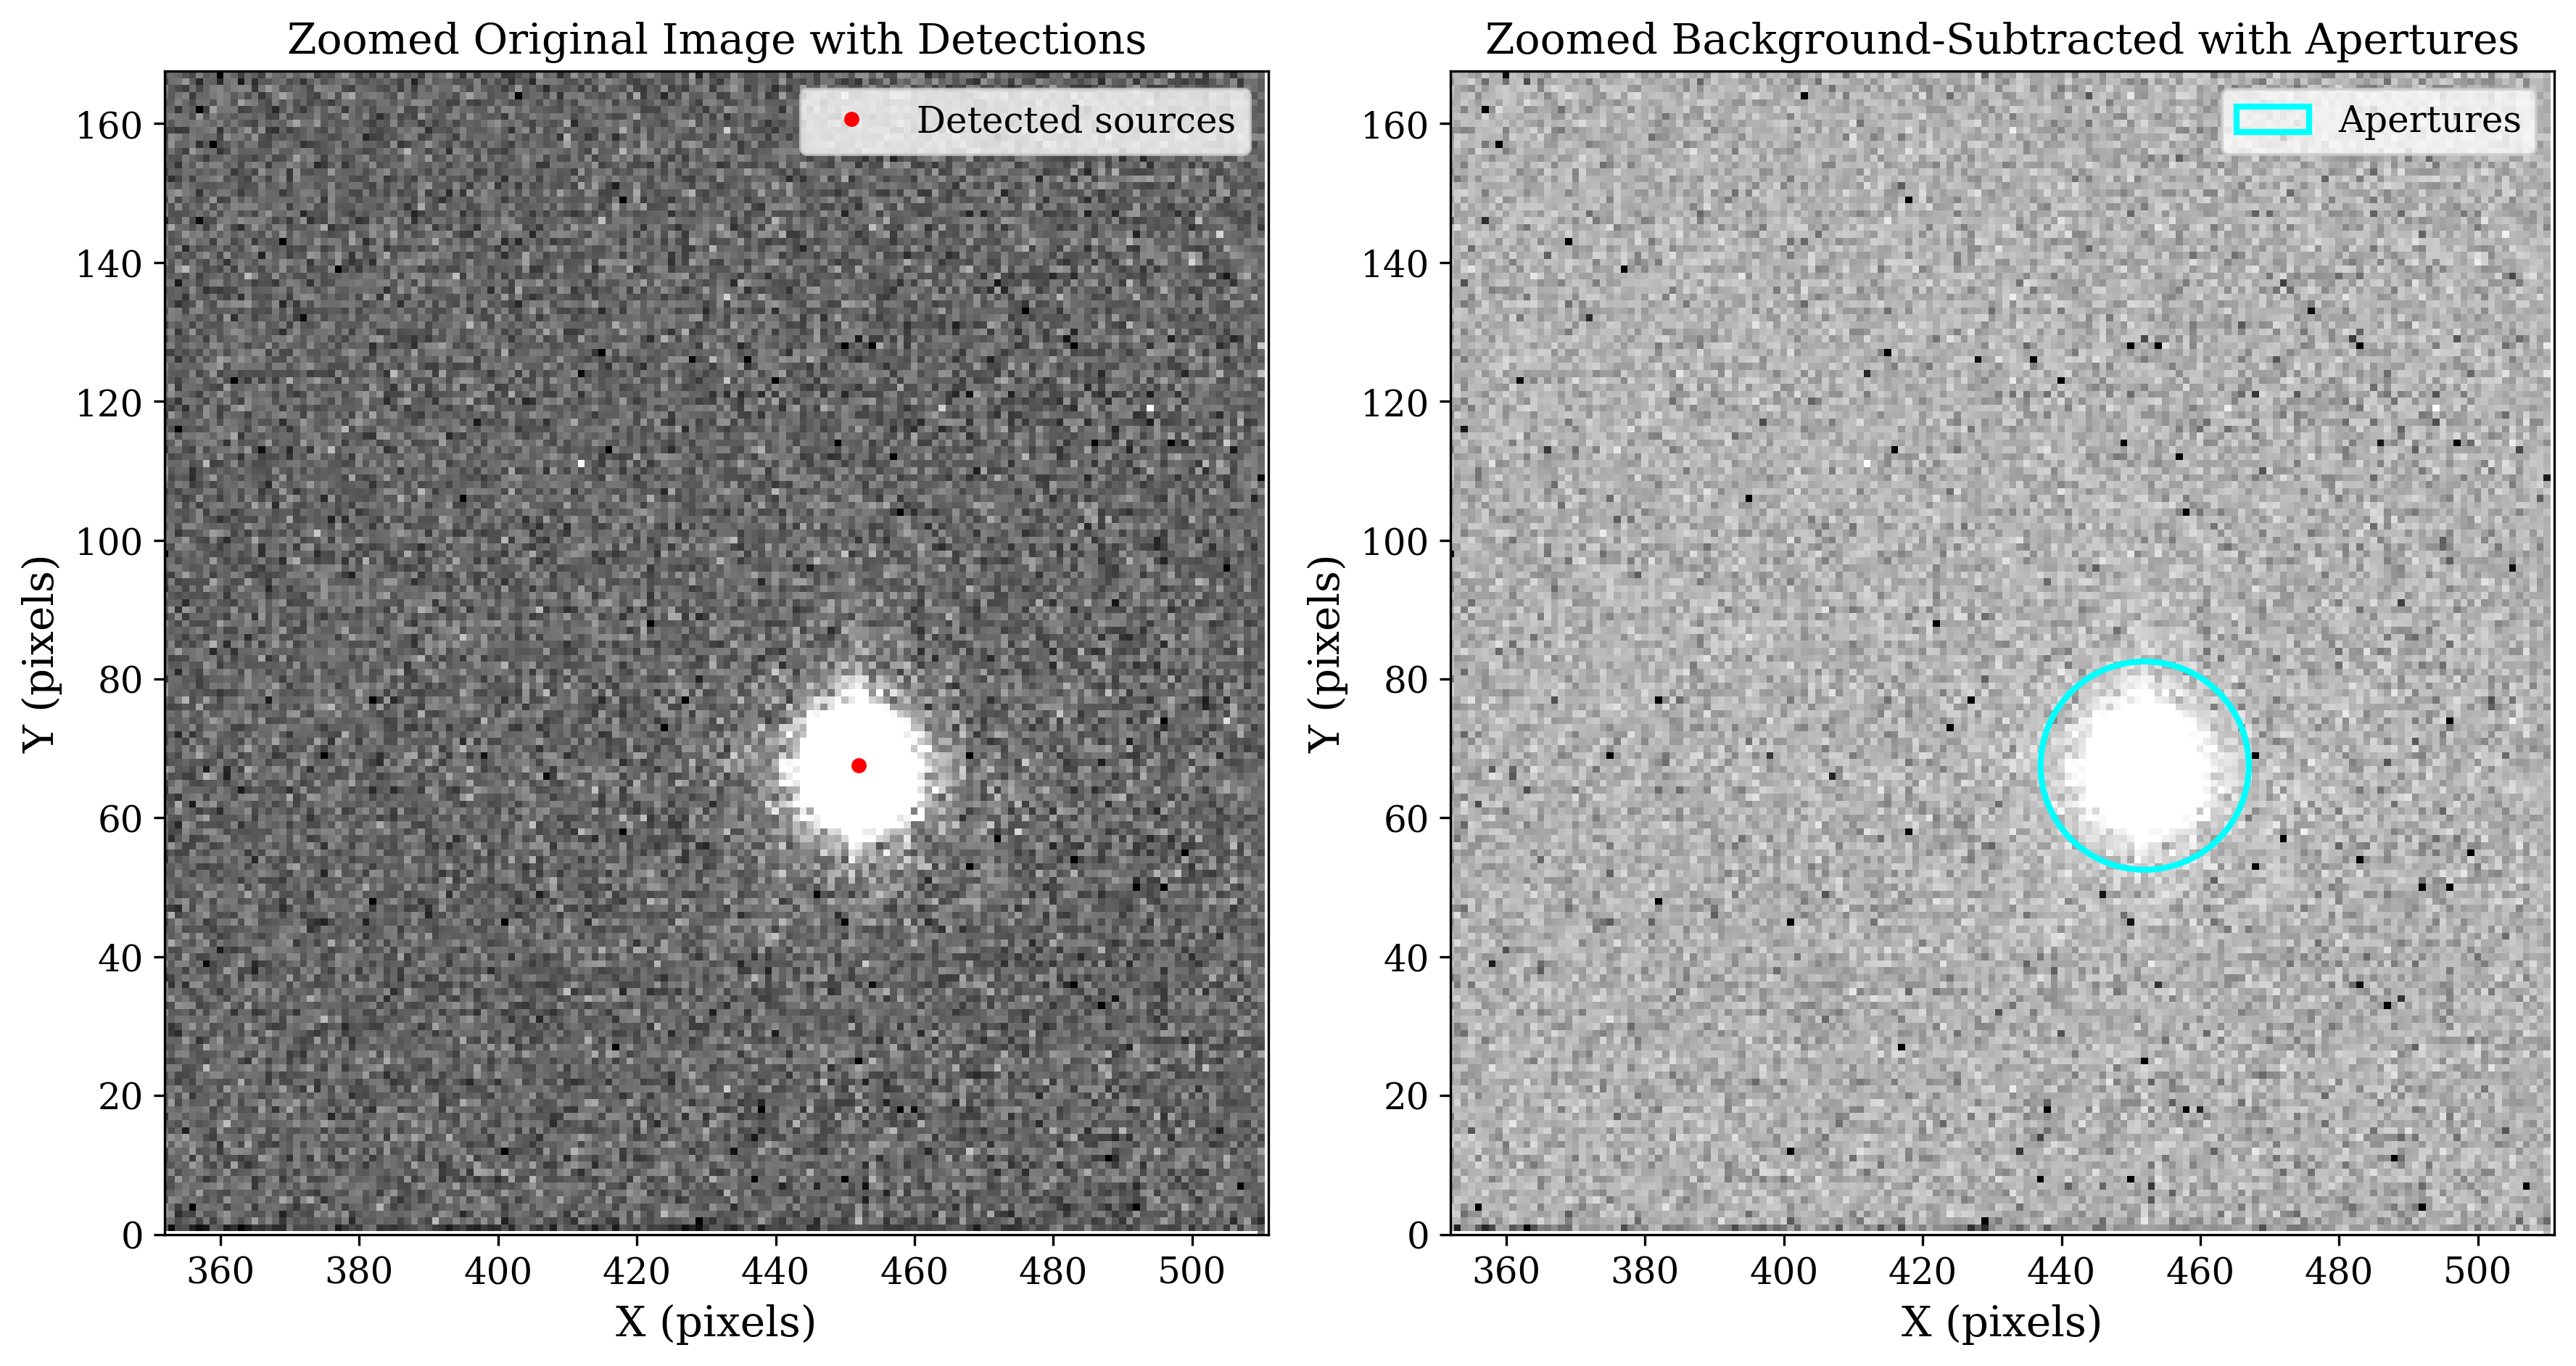

 id      xcenter           ycenter      ...  aperture_sum_err         snr       
--- ----------------- ----------------- ... ------------------ -----------------
  1 451.9878678206517 67.52512208343839 ... 16371.229077886002 298.3063686362646
Results saved to 'aperture_photometry_results.fits'


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.stats import sigma_clipped_stats, SigmaClip
from astropy.visualization import ZScaleInterval, ImageNormalize, LinearStretch, AsinhStretch  # Added LinearStretch and AsinhStretch
from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture, aperture_photometry
from photutils.utils import calc_total_error  # Added for error computation
from photutils.background import Background2D, MedianBackground

# Define paths (adjust if needed)
name = "comb_cfbo_DIRECTV14_0394_ov_5s_1"
path = "/home/allon/Escritorio/new_ptcs/bsw/sci_imageshh3/DIRECTV14_V_Red22/comb/"
obj = path + name + ".fits"

# Load the FITS image with diagnostics
with fits.open(obj) as hdul:
    print(f"FITS file: {obj}")
    print(f"Number of HDUs: {len(hdul)}")
    
    # Inspect each HDU
    for i, hdu in enumerate(hdul):
        print(f"HDU {i}: {hdu.header.get('XTENSION', 'PRIMARY')} - Shape: {getattr(hdu.data, 'shape', 'No data')}")
    
    # Load data from the first HDU with data (often HDU 1 for images)
    data = None
    header = None
    for i in range(len(hdul)):
        if hdul[i].data is not None and len(hdul[i].data.shape) == 2:  # Assume 2D image
            data = hdul[i].data.astype(float)  # Convert to float for processing
            header = hdul[i].header
            print(f"Data loaded from HDU {i}, shape: {data.shape}")
            break
    
    if data is None:
        raise ValueError("No 2D image data found in any HDU. Check file structure.")

# Compute background and subtract it
bkg = Background2D(data, box_size=(50, 50), filter_size=(3, 3), sigma_clip=SigmaClip(sigma=3.0))
bkg_data = bkg.background
data_sub = data - bkg_data  # This is the full-frame background-subtracted image

# Estimate noise for detection (use sigma-clipped stats on background)
_, bkg_rms, _ = sigma_clipped_stats(bkg_data, sigma=3.0)
print(f"Background RMS: {bkg_rms:.2f} ADU")

# Detect sources using DAOStarFinder (stricter threshold for fewer detections, focusing on bright spot)
daofind = DAOStarFinder(fwhm=3.0, threshold=10.0 * 130)  # Adjust multiplier or set fixed threshold (e.g., 200.0)
sources = daofind(data_sub)

if sources is None:
    sources = daofind(data_sub)
    print("No sources detected; check threshold/FWHM.")

# Extract positions (x, y in pixels)
positions = np.transpose((sources['xcentroid'], sources['ycentroid']))

# Define aperture radius (e.g., 3 * FWHM; adjust based on seeing)
aperture_radius = 15.0  # in pixels

# Perform aperture photometry
apertures = CircularAperture(positions, r=aperture_radius)
phot_table = aperture_photometry(data_sub, apertures)

# Add magnitude column (assuming zero-point from header or set manually)
zeropoint = header.get('ZP', 0.0)  # Replace with actual ZP if known

# Compute magnitudes, masking invalid sums
valid_mask = phot_table['aperture_sum'] > 0
phot_table['mag'] = np.full(len(phot_table), np.nan)  # Initialize with NaN
phot_table['mag'][valid_mask] = -2.5 * np.log10(phot_table['aperture_sum'][valid_mask]) + zeropoint

# Compute errors and SNR (requires gain and RON; use values from your earlier config)
gain = 1 / 53.4  # e-/ADU from your SExtractor config; adjust if needed
ron = 1.85  #4.68 e- in 1st channel |gain = 53.4| # Readout noise in e-/pixel; measure or adjust based on your CCD

# Background error map (global for simplicity; use local if bkg has variance map)
bkg_error = np.full_like(data, bkg_rms)  # Uniform background RMS
ron_term = ron / gain  # In ADU
bkg_error_with_ron = np.sqrt(bkg_error ** 2 + ron_term ** 2)

# Total error map including source Poisson
effective_gain = gain
total_error = calc_total_error(data_sub, bkg_error_with_ron, effective_gain)

# Re-run photometry with error map to get aperture_sum_err
phot_table_err = aperture_photometry(data_sub, apertures, error=total_error)

# Add error and SNR columns
phot_table['aperture_sum_err'] = phot_table_err['aperture_sum_err']
phot_table['snr'] = np.full(len(phot_table), np.nan)  # Initialize with NaN
phot_table['snr'][valid_mask] = phot_table['aperture_sum'][valid_mask] / phot_table['aperture_sum_err'][valid_mask]

# Find the brightest source for zooming (highest aperture sum)
if len(phot_table) > 0:
    brightest_idx = np.argmax(phot_table['aperture_sum'])
    bright_pos = positions[brightest_idx]
    zoom_size = 100  # Pixels around the bright spot; adjust as needed (e.g., 50 for tighter zoom)
    x_min, x_max = max(0, bright_pos[0] - zoom_size), min(data.shape[1], bright_pos[0] + zoom_size)
    y_min, y_max = max(0, bright_pos[1] - zoom_size), min(data.shape[0], bright_pos[1] + zoom_size)
    print(f"Brightest source at ({bright_pos[0]:.1f}, {bright_pos[1]:.1f}), zooming to [{x_min:.1f}:{x_max:.1f}, {y_min:.1f}:{y_max:.1f}]")
else:
    x_min, x_max, y_min, y_max = 0, data.shape[1], 0, data.shape[0]  # Full frame if no sources

# Visualization: Plot zoomed views around the bright spot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

# Left: Zoomed original image with detected sources marked
norm1 = ImageNormalize(data, interval=ZScaleInterval(), stretch=LinearStretch())  # Fixed: Use LinearStretch() instance
ax1.imshow(data, norm=norm1, cmap='gray', origin='lower')
ax1.plot(positions[:, 0], positions[:, 1], 'o', color='red', markersize=4, label='Detected sources')
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)
ax1.set_title('Zoomed Original Image with Detections')
ax1.set_xlabel('X (pixels)')
ax1.set_ylabel('Y (pixels)')
ax1.legend()

# Right: Zoomed background-subtracted with apertures overlaid
norm2 = ImageNormalize(data_sub, interval=ZScaleInterval(), stretch=AsinhStretch())  # Fixed: Use AsinhStretch() instance
ax2.imshow(data_sub, norm=norm2, cmap='gray', origin='lower')
apertures.plot(axes=ax2, color='cyan', lw=2, label='Apertures')
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)
ax2.set_title('Zoomed Background-Subtracted with Apertures')
ax2.set_xlabel('X (pixels)')
ax2.set_ylabel('Y (pixels)')
ax2.legend()

plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.savefig('photometry_visualization_zoomed.png', dpi=150, bbox_inches='tight')  # Save zoomed plot
plt.show()  # Display interactively

# Print summary of photometry results (filter for positive sums and SNR > 5)
positive_snr_mask = (phot_table['aperture_sum'] > 0) & (phot_table['snr'] > 5)
print(phot_table[positive_snr_mask])  # Show only valid, high-SNR photometry

# Optional: Save catalog to FITS table
phot_table.write('aperture_photometry_results.fits', overwrite=True)
print("Results saved to 'aperture_photometry_results.fits'")

In [14]:
#2	451.98512531424973	67.52695600771035	4921362.516489296	-16.730213392829125	17726.434808408474	277.6284441671748

FITS file: /home/allon/Escritorio/new_ptcs/bsw/sci_imageshh3/DIRECTV14_V_Red22/notComb/cfbo_DIRECTV14_0394.fits
Number of HDUs: 17
HDU 0: PRIMARY - Shape: No data
HDU 1: IMAGE - Shape: (200, 511)
HDU 2: IMAGE - Shape: (200, 511)
HDU 3: IMAGE - Shape: (200, 511)
HDU 4: IMAGE - Shape: (200, 511)
HDU 5: IMAGE - Shape: (200, 511)
HDU 6: IMAGE - Shape: (200, 511)
HDU 7: IMAGE - Shape: (200, 511)
HDU 8: IMAGE - Shape: (200, 511)
HDU 9: IMAGE - Shape: (200, 511)
HDU 10: IMAGE - Shape: (200, 511)
HDU 11: IMAGE - Shape: (200, 511)
HDU 12: IMAGE - Shape: (200, 511)
HDU 13: IMAGE - Shape: (200, 511)
HDU 14: IMAGE - Shape: (200, 511)
HDU 15: IMAGE - Shape: (200, 511)
HDU 16: IMAGE - Shape: (200, 511)
Data loaded from HDU 1, shape: (200, 511)
Background RMS: 22.45 ADU
Brightest source at (254.0, -0.0), zooming to [154.0:354.0, 0.0:100.0]


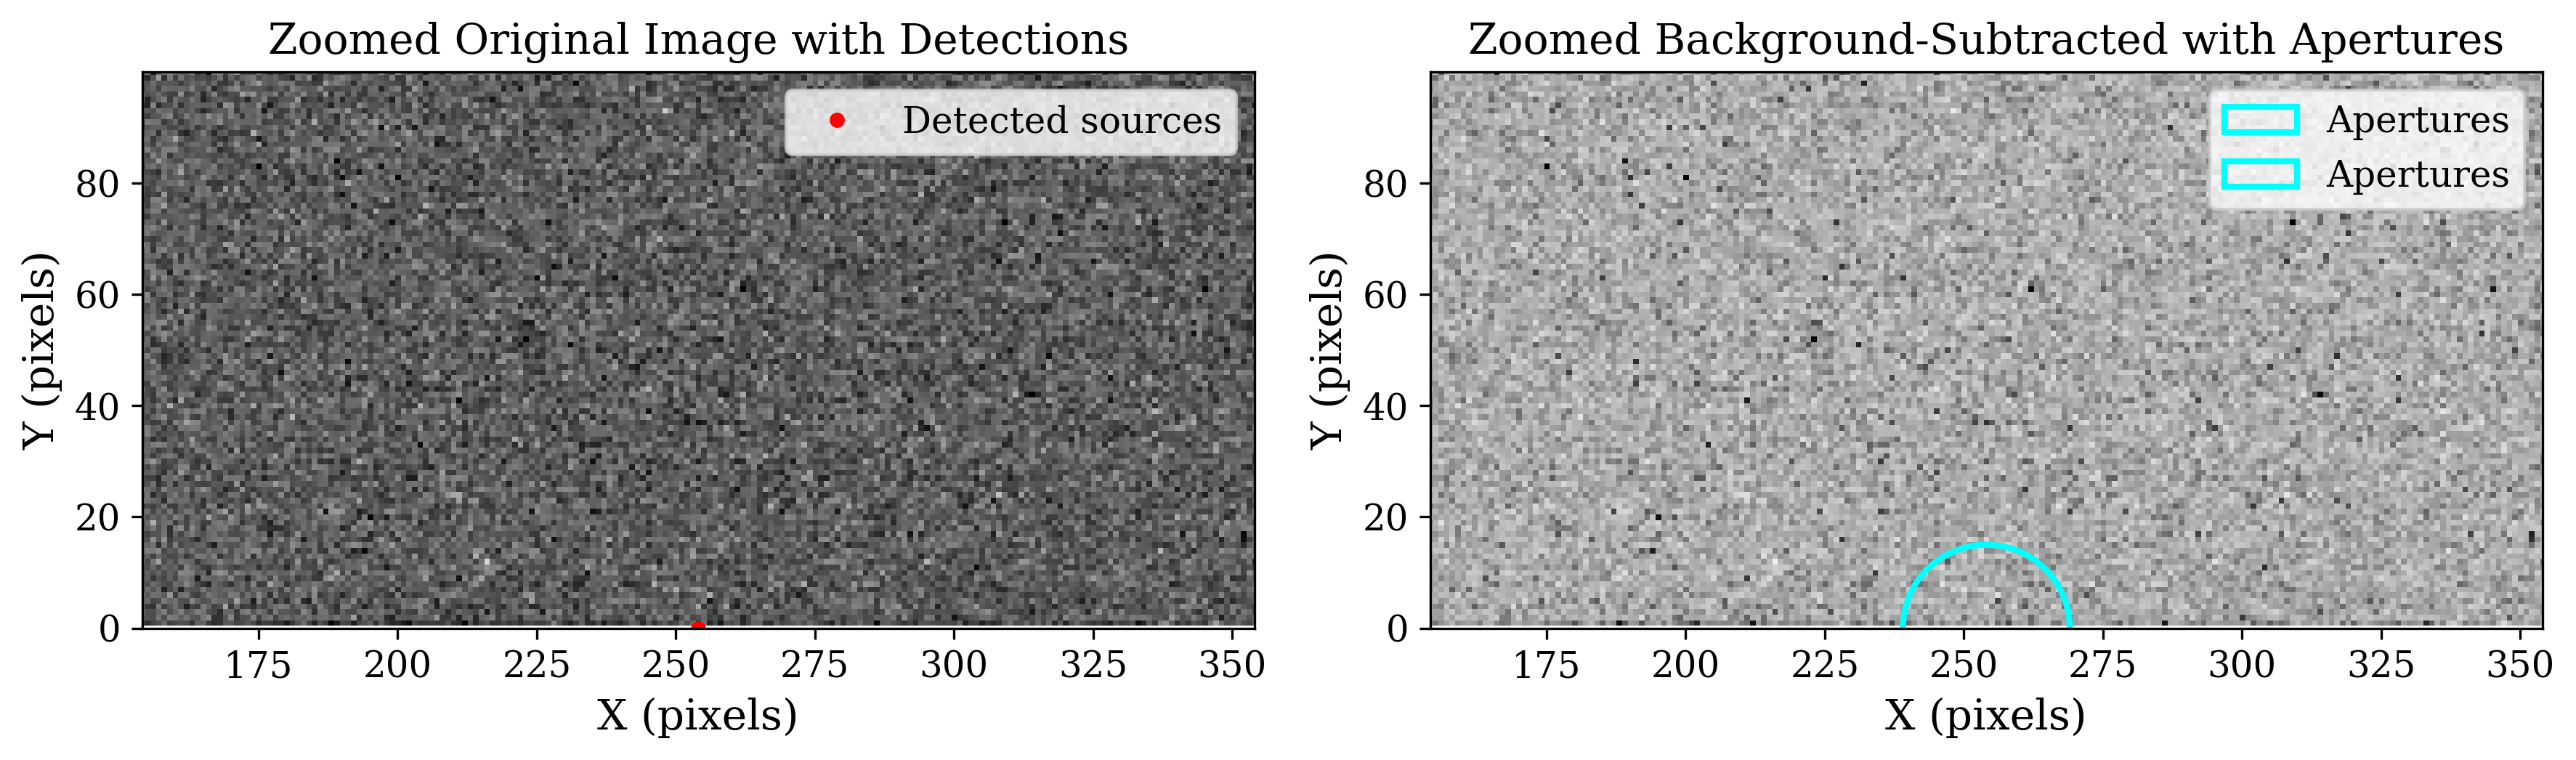

 id      xcenter       ...  aperture_sum_err         snr       
--- ------------------ ... ------------------ -----------------
  1 254.04611661006894 ... 17142.936785393355 289.6572055291323
  2 451.98512531424973 ... 17726.434808408474 277.6284441671748
Results saved to 'aperture_photometry_results.fits'


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.stats import sigma_clipped_stats, SigmaClip
from astropy.visualization import ZScaleInterval, ImageNormalize, LinearStretch, AsinhStretch  # Added LinearStretch and AsinhStretch
from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture, aperture_photometry
from photutils.utils import calc_total_error  # Added for error computation
from photutils.background import Background2D, MedianBackground

# Define paths (adjust if needed)
name = "cfbo_DIRECTV14_0394"
path = "/home/allon/Escritorio/new_ptcs/bsw/sci_imageshh3/DIRECTV14_V_Red22/notComb/"
obj = path + name + ".fits"

# Load the FITS image with diagnostics
with fits.open(obj) as hdul:
    print(f"FITS file: {obj}")
    print(f"Number of HDUs: {len(hdul)}")
    
    # Inspect each HDU
    for i, hdu in enumerate(hdul):
        print(f"HDU {i}: {hdu.header.get('XTENSION', 'PRIMARY')} - Shape: {getattr(hdu.data, 'shape', 'No data')}")
    
    # Load data from the first HDU with data (often HDU 1 for images)
    data = None
    header = None
    for i in range(len(hdul)):
        if hdul[i].data is not None and len(hdul[i].data.shape) == 2:  # Assume 2D image
            data = hdul[i].data.astype(float)  # Convert to float for processing
            header = hdul[i].header
            print(f"Data loaded from HDU {i}, shape: {data.shape}")
            break
    
    if data is None:
        raise ValueError("No 2D image data found in any HDU. Check file structure.")

# Compute background and subtract it
bkg = Background2D(data, box_size=(50, 50), filter_size=(3, 3), sigma_clip=SigmaClip(sigma=3.0))
bkg_data = bkg.background
data_sub = data - bkg_data  # This is the full-frame background-subtracted image

# Estimate noise for detection (use sigma-clipped stats on background)
_, bkg_rms, _ = sigma_clipped_stats(bkg_data, sigma=3.0)
print(f"Background RMS: {bkg_rms:.2f} ADU")

# Detect sources using DAOStarFinder (stricter threshold for fewer detections, focusing on bright spot)
daofind = DAOStarFinder(fwhm=3.0, threshold=10.0 * 260)  # Adjust multiplier or set fixed threshold (e.g., 200.0)
sources = daofind(data_sub)

if sources is None:
    sources = daofind(data_sub)
    print("No sources detected; check threshold/FWHM.")

# Extract positions (x, y in pixels)
positions = np.transpose((sources['xcentroid'], sources['ycentroid']))

# Define aperture radius (e.g., 3 * FWHM; adjust based on seeing)
aperture_radius = 15.0  # in pixels

# Perform aperture photometry
apertures = CircularAperture(positions, r=aperture_radius)
phot_table = aperture_photometry(data_sub, apertures)

# Add magnitude column (assuming zero-point from header or set manually)
zeropoint = header.get('ZP', 0.0)  # Replace with actual ZP if known

# Compute magnitudes, masking invalid sums
valid_mask = phot_table['aperture_sum'] > 0
phot_table['mag'] = np.full(len(phot_table), np.nan)  # Initialize with NaN
phot_table['mag'][valid_mask] = -2.5 * np.log10(phot_table['aperture_sum'][valid_mask]) + zeropoint

# Compute errors and SNR (requires gain and RON; use values from your earlier config)
gain = 1 / 53.4  # e-/ADU from your SExtractor config; adjust if needed
ron = 5  #4.68 e- in 1st channel |gain = 53.4| # Readout noise in e-/pixel; measure or adjust based on your CCD

# Background error map (global for simplicity; use local if bkg has variance map)
bkg_error = np.full_like(data, bkg_rms)  # Uniform background RMS
ron_term = ron / gain  # In ADU
bkg_error_with_ron = np.sqrt(bkg_error ** 2 + ron_term ** 2)

# Total error map including source Poisson
effective_gain = gain
total_error = calc_total_error(data_sub, bkg_error_with_ron, effective_gain)

# Re-run photometry with error map to get aperture_sum_err
phot_table_err = aperture_photometry(data_sub, apertures, error=total_error)

# Add error and SNR columns
phot_table['aperture_sum_err'] = phot_table_err['aperture_sum_err']
phot_table['snr'] = np.full(len(phot_table), np.nan)  # Initialize with NaN
phot_table['snr'][valid_mask] = phot_table['aperture_sum'][valid_mask] / phot_table['aperture_sum_err'][valid_mask]

# Find the brightest source for zooming (highest aperture sum)
if len(phot_table) > 0:
    brightest_idx = np.argmax(phot_table['aperture_sum'])
    bright_pos = positions[brightest_idx]
    zoom_size = 100  # Pixels around the bright spot; adjust as needed (e.g., 50 for tighter zoom)
    x_min, x_max = max(0, bright_pos[0] - zoom_size), min(data.shape[1], bright_pos[0] + zoom_size)
    y_min, y_max = max(0, bright_pos[1] - zoom_size), min(data.shape[0], bright_pos[1] + zoom_size)
    print(f"Brightest source at ({bright_pos[0]:.1f}, {bright_pos[1]:.1f}), zooming to [{x_min:.1f}:{x_max:.1f}, {y_min:.1f}:{y_max:.1f}]")
else:
    x_min, x_max, y_min, y_max = 0, data.shape[1], 0, data.shape[0]  # Full frame if no sources

# Visualization: Plot zoomed views around the bright spot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

# Left: Zoomed original image with detected sources marked
norm1 = ImageNormalize(data, interval=ZScaleInterval(), stretch=LinearStretch())  # Fixed: Use LinearStretch() instance
ax1.imshow(data, norm=norm1, cmap='gray', origin='lower')
ax1.plot(positions[:, 0], positions[:, 1], 'o', color='red', markersize=4, label='Detected sources')
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)
ax1.set_title('Zoomed Original Image with Detections')
ax1.set_xlabel('X (pixels)')
ax1.set_ylabel('Y (pixels)')
ax1.legend()

# Right: Zoomed background-subtracted with apertures overlaid
norm2 = ImageNormalize(data_sub, interval=ZScaleInterval(), stretch=AsinhStretch())  # Fixed: Use AsinhStretch() instance
ax2.imshow(data_sub, norm=norm2, cmap='gray', origin='lower')
apertures.plot(axes=ax2, color='cyan', lw=2, label='Apertures')
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)
ax2.set_title('Zoomed Background-Subtracted with Apertures')
ax2.set_xlabel('X (pixels)')
ax2.set_ylabel('Y (pixels)')
ax2.legend()

plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.savefig('photometry_visualization_zoomed.png', dpi=150, bbox_inches='tight')  # Save zoomed plot
plt.show()  # Display interactively

# Print summary of photometry results (filter for positive sums and SNR > 5)
positive_snr_mask = (phot_table['aperture_sum'] > 0) & (phot_table['snr'] > 5)
print(phot_table[positive_snr_mask])  # Show only valid, high-SNR photometry

# Optional: Save catalog to FITS table
phot_table.write('aperture_photometry_results.fits', overwrite=True)
print("Results saved to 'aperture_photometry_results.fits'")

In [13]:
phot_table

id,xcenter,ycenter,aperture_sum,mag,aperture_sum_err,snr
int64,float64,float64,float64,float64,float64,float64
1,254.04611661006894,-0.00018660019702219105,4965575.1638196055,-16.73992390046009,17142.936785393355,289.6572055291323
2,451.98512531424973,67.52695600771035,4921362.516489296,-16.730213392829125,17726.434808408474,277.6284441671748


# Curva de luz

In [ ]:
# # --- Leer tabla ---
# #name = "light_curve_comb_cfbo_STARONED1_V_ROI0101_ov_5s_1_obj0" y 1
# #path = "/home/allon/Escritorio/new_ptcs/bsw/sci_imageshh3/STARONED1_MaybeRedLast17/"

# # name = "light_curve_comb_cfbo_DIRECTV14_0310_r_5s_1_obj0"
# # path = "/home/allon/Escritorio/new_ptcs/bsw/sci_imageshh3/DIRECTV14_R_Red22/comb/"

# name = "light_curve_comb_cfbo_DIRECTV14_0394_ov_5s_1_obj0"
# path = "/home/allon/Escritorio/new_ptcs/bsw/sci_imageshh3/DIRECTV14_V_Red22/comb/"

# # name = "light_curve_comb_cfbo_toi6735Ok_0132_ov_15s_1_obj0" #Eclipsing binary
# # path = "/home/allon/Escritorio/new_ptcs/bsw/sci_imageshh2d7mixed/reduced/comb/"

# # name = "light_curve_comb_cfbo_toi4948roi_0030_ov_10s_1_obj0"
# # path = "/home/allon/Escritorio/new_ptcs/bsw/sci_imageshh2d7mixed/toi4948_Red/comb/"

# filename = path + name + ".txt"

# df = pd.read_csv(filename, sep="|", comment="#", engine="python")
# df.columns = df.columns.str.strip()
# for col in df.columns:
#     if df[col].dtype == "object":
#         df[col] = df[col].str.strip()
# df = df.dropna(axis=1, how="all").dropna(how="all")
# df = df.astype(float)

# # --- Normalizar MJD ---
# MJD0 = df["MJD"].min()
# df["dMJD"] = df["MJD"] - MJD0

# # --- Plot ---
# fig, ax = plt.subplots(figsize=(6,4))
# ax.errorbar(df["dMJD"], df["MAG_WIN"], yerr=df["MAGERR_WIN"],
#             fmt='o', color='black', markersize=3,
#             elinewidth=0.8, capsize=1.5)

# ax.invert_yaxis()
# ax.set_xlabel(f"MJD – {MJD0:.3f} (days)")
# ax.set_ylabel("$m_{V}$ (mag)")
# #ax.set_title("Light Curve")

# plt.tight_layout()
# #plt.savefig(f"{name}.png")
# plt.show()